# 3Di alignment benchmark

## Description

We compare the performance of ESM3Di, compared to ProstT5, on the MetaVR sequence set.

We have 3 different 3Di representations of the MetaVR sequence set:
* `AF3`: 3Di generated by Foldseek based on the predicted AlphaFold3 structures of the MetaVR sequence set.
* `ProstT5`: 3Di generated by ProstT5 based on the sequences of the MetaVR sequence set.
* `ESM3Di`: 3Di generated by ESM3Di based on the sequences of the MetaVR sequence set.

We compile each representation into a Foldseek database, run Foldseek `structurealign` module with 1-vs-1 basis (aligning identical entries).

The results are represented as the bitscore of the alignment, and 3Di sequence identity, which can be calculated as: 
$\text{Identity} = \frac{\text{\# of residues with identical 3Di}}{\text{\# of residues}}$

---

## Database preparation

### Download and process the MetaVR dataset

In [ ]:
from pathlib import Path
import os

DATAPATH = Path("/mnt/data1/metavir_structs").resolve()
os.environ["DATAPATH"] = str(DATAPATH)
print(f"DATAPATH set to: {DATAPATH}")

DATAPATH set to: /mnt/data1/metavir_structs


In [42]:
%%bash
# Download MetaVR dataset
mkdir -p "$DATAPATH/metavr"
#wget -q -O "$DATAPATH/metavr/IMGVR5_PC_3Dmodels.tar.gz" "https://www.meta-virome.org/Data/Downloads/IMGVR5_PC_3Dmodels.tar.gz"
#tar -xzf "$DATAPATH/metavr/IMGVR5_PC_3Dmodels.tar.gz" -C "$DATAPATH/metavr"

In [45]:
%%bash
# Create Foldseek database
if [ -d "$DATAPATH/foldseek" ]; then
    rm -rf "$DATAPATH/foldseek"/*
else
    mkdir -p "$DATAPATH/foldseek"
fi



In [46]:
%%bash
mkdir -p "$DATAPATH/foldseek"

foldseek createdb "$DATAPATH/metavr/metaVR_structures_10k" "$DATAPATH/foldseek/metavr_af3"

createdb /mnt/data1/metavir_structs/metavr/metaVR_structures_10k /mnt/data1/metavir_structs/foldseek/metavr_af3 

MMseqs Version:             	10.941cd33
Use GPU                     	0
Path to ProstT5             	
Chain name mode             	0
Createdb extraction mode    	0
Interface distance threshold	8
Write mapping file          	0
Mask b-factor threshold     	0
Coord store mode            	2
Write lookup file           	1
Input format                	0
File Inclusion Regex        	.*
File Exclusion Regex        	^$
Threads                     	32
Verbosity                   	3

Output file: /mnt/data1/metavir_structs/foldseek/metavr_af3
[=================================================================] 10.00K 3s 22ms
Time for merging to metavr_af3_ss: 0h 0m 0s 13ms
Time for merging to metavr_af3_h: 0h 0m 0s 6ms
Time for merging to metavr_af3_ca: 0h 0m 0s 22ms
Time for merging to metavr_af3: 0h 0m 0s 8ms
Ignore 0 out of 10000.
Too short: 0, incorrect: 0, not proteins: 0.
Time for

### Predict 3Di representations with ProstT5

#### Generate AA FASTA file from the MetaVR dataset

In [47]:
%%bash
awk '{gsub(/\x00/, "", $0)} NR==FNR{f[FNR]=$0; next} f[FNR]{print ">"f[FNR]"\n"$0}' \
	"$DATAPATH/foldseek/metavr_af3_h" \
	"$DATAPATH/foldseek/metavr_af3" \
	> "$DATAPATH/metavr/metavr_aa.fa"

grep -v "^>" "$DATAPATH/metavr/metavr_aa.fa" | wc -l

10000


#### Predict 3Di with ProstT5

In [48]:
%%bash
#foldseek databases ProstT5 "$DATAPATH/prostt5_weights" "$DATAPATH/tmp"
rm -rf "$DATAPATH/tmp"
foldseek createdb "$DATAPATH/metavr/metavr_aa.fa" "$DATAPATH/foldseek/metavr_prostt5" --gpu 1 --prostt5-model "$DATAPATH/prostt5_weights"

createdb /mnt/data1/metavir_structs/metavr/metavr_aa.fa /mnt/data1/metavir_structs/foldseek/metavr_prostt5 --gpu 1 --prostt5-model /mnt/data1/metavir_structs/prostt5_weights 

MMseqs Version:             	10.941cd33
Use GPU                     	1
Path to ProstT5             	/mnt/data1/metavir_structs/prostt5_weights
Chain name mode             	0
Createdb extraction mode    	0
Interface distance threshold	8
Write mapping file          	0
Mask b-factor threshold     	0
Coord store mode            	2
Write lookup file           	1
Input format                	0
File Inclusion Regex        	.*
File Exclusion Regex        	^$
Threads                     	32
Verbosity                   	3

Converting sequences
[
Time for merging to metavr_prostt5_h: 0h 0m 0s 3ms
Time for merging to metavr_prostt5: 0h 0m 0s 5ms
Database type: Aminoacid
CUDA0
CUDA1
CPU
[=================================================================] 10.00K 8m 17s 417ms
Time for merging to metavr_prostt5_ss: 0h 0m 0s 7ms
T

In [114]:
%%bash
pwd

/home/dmoi/projects/ESM3di/benchmark


### Predict 3Di representations with ESM3Di

In [113]:
%%bash
# Predict 3Di with ESM3Di and build the Foldseek database.
# Update MODEL_CKPT to the checkpoint you want to use.
MODEL_CKPT="../checkpoints/esm3di_from_mlm/epoch_5.pt"
#MODEL_CKPT="../checkpoints_ESMplusplus_small/epoch_3.pt"
#MODEL_CKPT="../checkpoints_prostt5_bfvd_plddt_aux/epoch_30.pt"
python -m esm3di.fastas2foldseekdb \
	--aa-fasta "$DATAPATH/metavr/metavr_aa.fa" \
	--model-ckpt "$MODEL_CKPT" \
	--output-db "$DATAPATH/foldseek/metavr_esm3di" \
	--keep-fastas

Checking for FoldSeek installation...
✓ FoldSeek found

Running ESM inference on /mnt/data1/metavir_structs/metavr/metavr_aa.fa...
Using model: ../checkpoints/esm3di_from_mlm/epoch_5.pt
Device: cuda
Loading model configuration from checkpoint...
Using 2 GPU(s) for inference on 10000 sequences


Multi-GPU inference:   0%|          | 0/2 [00:05<?, ?GPU/s]


Falling back to single-GPU inference...
Using single GPU: cuda
Initializing ESM3DiModel with Synthyra/ESMplusplus_small...

Loading model: Synthyra/ESMplusplus_small


Traceback (most recent call last):
  File "/home/dmoi/miniforge3/envs/fastas2foldseekdb/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/dmoi/miniforge3/envs/fastas2foldseekdb/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/dmoi/projects/ESM3di/esm3di/fastas2foldseekdb.py", line 1017, in <module>
    main()
  File "/home/dmoi/projects/ESM3di/esm3di/fastas2foldseekdb.py", line 928, in main
    model = ESM3DiModel(
  File "/home/dmoi/projects/ESM3di/esm3di/ESM3di_model.py", line 1006, in __init__
    self._load_model()
  File "/home/dmoi/projects/ESM3di/esm3di/ESM3di_model.py", line 1098, in _load_model
    self.base_model = AutoModelForTokenClassification.from_pretrained(
  File "/home/dmoi/miniforge3/envs/fastas2foldseekdb/lib/python3.10/site-packages/transformers/models/auto/auto_factory.py", line 526, in from_pretrained
    config, kwargs = AutoConfig.from_pretrained(
  Fi

Error while terminating subprocess (pid=4090073): 


TypeError: %d format: a real number is required, not NoneType

In [ ]:
%%bash
echo $DATAPATH

grep ">" "$DATAPATH/foldseek/metavr_esm3di_3di.fasta" | wc -l

grep ">" "$DATAPATH/metavr/metavr_aa.fa" | wc -l

/mnt/data1/metavir_structs
10000
10000


In [ ]:
from esm3di.fastas2foldseekdb import create_foldseek_db_from_fastas
create_foldseek_db_from_fastas(
	aa_fasta=str(DATAPATH / "metavr/metavr_aa.fa"),
	three_di_fasta=str(DATAPATH / "foldseek/metavr_esm3di_3di.fasta"),
	output_db=str(DATAPATH / "foldseek/metavr_db"),
	foldseek_bin="foldseek",
	aafile_tsv=None,
	three_di_tsv=None,
	header_tsv=None
	)

#DATAPATH/metavr/metavr_aa.fa

✓ Read 10000 amino acid sequences and 10000 3Di sequences


10000it [00:00, 348378.59it/s]

10000 sequences written to TSV files
AA TSV lines: 10000
3Di TSV lines: 10000
Header TSV lines: 10000
Running: foldseek tsv2db /mnt/data1/metavir_structs/foldseek/metavr_db_aa.tsv /mnt/data1/metavir_structs/foldseek/metavr_db --output-dbtype 0 -v 3
/mnt/data1/metavir_structs/foldseek/metavr_db exists and will be overwritten
tsv2db /mnt/data1/metavir_structs/foldseek/metavr_db_aa.tsv /mnt/data1/metavir_structs/foldseek/metavr_db --output-dbtype 0 -v 3 

MMseqs Version:           	10.941cd33
Output database type      	0
Compressed                	0
Verbosity                 	3

Output database type: Aminoacid
Time for merging to metavr_db: 0h 0m 0s 2ms
Time for processing: 0h 0m 0s 12ms

Running: foldseek tsv2db /mnt/data1/metavir_structs/foldseek/metavr_db_3di.tsv /mnt/data1/metavir_structs/foldseek/metavr_db_ss --output-dbtype 0 -v 3


/mnt/data1/metavir_structs/foldseek/metavr_db_ss exists and will be overwritten
tsv2db /mnt/data1/metavir_structs/foldseek/metavr_db_3di.tsv /mnt/data1/metavir_structs/foldseek/metavr_db_ss --output-dbtype 0 -v 3 

MMseqs Version:           	10.941cd33
Output database type      	0
Compressed                	0
Verbosity                 	3

Output database type: Aminoacid
Time for merging to metavr_db_ss: 0h 0m 0s 2ms
Time for processing: 0h 0m 0s 13ms

Running: foldseek tsv2db /mnt/data1/metavir_structs/foldseek/metavr_db_header.tsv /mnt/data1/metavir_structs/foldseek/metavr_db_h --output-dbtype 15 -v 3
/mnt/data1/metavir_structs/foldseek/metavr_db_h exists and will be overwritten
tsv2db /mnt/data1/metavir_structs/foldseek/metavr_db_header.tsv /mnt/data1/metavir_structs/foldseek/metavr_db_h --output-dbtype 15 -v 3 

MMseqs Version:           	10.941cd33
Output database type      	15
Compressed                	0
Verbosity                 	3

Output database type: Offsetted headers
Time f

True

In [ ]:



def _open_if_is_name(filename_or_handle, mode="r"):
	"""
		if a file handle is passed, return the file handle
		if a Path object or path string is passed, open and return a file handle to the file.
		returns:
			file_handle, input_type ("name" | "handle")
	"""
	out = filename_or_handle
	input_type = "handle"
	try:
		out = open(filename_or_handle, mode)
		input_type = "name"
	except TypeError:
		pass
	except Exception as e:
		raise(e)

	return (out, input_type)



def iter_fasta(filename, clean=None, full_name=False): 
	"""
		adapted from: https://bitbucket.org/seanrjohnson/srj_chembiolib/src/master/parsers.py
		
		input:
			filename: the name of a fasta file or a filehandle to a fasta file.
			return_names: if True then return two lists: (names, sequences), otherwise just return list of sequences
			clean: {None, 'upper', 'delete', 'unalign'}
					if 'delete' then delete all lowercase "." and "*" characters. This is usually if the input is an a2m file and you don't want to preserve the original length.
					if 'upper' then delete "*" characters, convert lowercase to upper case, and "." to "-"
					if 'unalign' then convert to upper, delete ".", "*", "-"
			full_name: if True, then returns the entire name. By default only the part before the first whitespace is returned.
		output: names, sequences
	"""
	
	prev_len = 0
	prev_name = None
	prev_seq = ""
	(input_handle, input_type) = _open_if_is_name(filename)

	seq_cleaner = CleanSeq(clean)

	for line in input_handle:
		line = line.strip()
		if len(line) == 0:
			continue
		if line[0] == ">":
			if full_name:
				name = line[1:]
			else:
				parts = line.split(None, 1)
				name = parts[0][1:]
			if (prev_name is not None):
				yield prev_name, seq_cleaner(prev_seq)
			prev_len = 0
			prev_name = name
			prev_seq = ""
		else:
			prev_len += len(line)
			prev_seq += line
	if (prev_name != None):
		yield prev_name, seq_cleaner(prev_seq)
		

	if input_type == "name":
		input_handle.close()


class CleanSeq():
	def __init__(self, clean=None):
		self.clean = clean
		if clean == 'delete':
			# uses code from: https://github.com/facebookresearch/esm/blob/master/examples/contact_prediction.ipynb
			deletekeys = dict.fromkeys(string.ascii_lowercase)
			deletekeys["."] = None
			deletekeys["*"] = None
			translation = str.maketrans(deletekeys)
			self.remove_insertions = lambda x: x.translate(translation)
		elif clean == 'upper':
			deletekeys = {'*': None, ".": "-"}
			translation = str.maketrans(deletekeys)
			self.remove_insertions = lambda x: x.upper().translate(translation)
			

		elif clean == 'unalign':
			deletekeys = {'*': None, ".": None, "-": None}
			
			translation = str.maketrans(deletekeys)
			self.remove_insertions = lambda x: x.upper().translate(translation)
		
		elif clean is None:
			self.remove_insertions = lambda x: x
		
		else:
			raise ValueError(f"unrecognized input for clean parameter: {clean}")
		
	def __call__(self, seq):
		return self.remove_insertions(seq)

	def __repr__(self):
		return f"CleanSeq(clean={self.clean})"


def fasta2foldseek(aa_fasta, tdi_fasta, output_basename):
	# write the dbtypes
	
	#TODO: do I need to make the .lookup file?

	# pep dbtype
	with open(output_basename+".dbtype","wb") as pep_dbtype:
		pep_dbtype.write(b'\x00\x00\x00\x00')

	# 3Di dbtype
	with open(output_basename+"_ss.dbtype","wb") as tdi_dbtype:
		tdi_dbtype.write(b'\x00\x00\x00\x00')

	# headers dbtype
	with open(output_basename+"_h.dbtype","wb") as h_dbtype:
		h_dbtype.write(b'\x00\x0c\x00\x00')
		
	
	with open(f"{output_basename}","wb") as aa_h, open(f"{output_basename}_ss","wb") as tdi_h, open(f"{output_basename}_h","wb") as header_h, \
		 open(f"{output_basename}.index","wb") as aa_index_h, open(f"{output_basename}_ss.index","wb") as tdi_index_h, open(f"{output_basename}_h.index","wb") as header_index_h, \
		 open(f"{output_basename}.lookup","wb") as lookup_h, \
		 open(tdi_fasta, "r") as tdi_in, open(aa_fasta, "r") as pep_in:
		tdi_iter = iter_fasta(tdi_in, full_name=True)

		seq_index = -1
		for pep_header, pep_seq in iter_fasta(pep_in, full_name=True):
			pep_name = pep_header.split(' ')[0]
			tdi_header, tdi_seq = next(tdi_iter)
			tdi_name = tdi_header.split(' ')[0]
			assert pep_header == tdi_header, f"Headers do not match: {pep_header} != {tdi_header}"
			assert pep_name == tdi_name, f"Names do not match: {pep_name} != {tdi_name}"
			assert len(pep_seq) == len(tdi_seq), f"Sequences do not match in length: {len(pep_seq)} != {len(tdi_seq)}"

			seq_index += 1
			
			# write the pep sequence
			aa_start_pos = aa_h.tell()
			aa_index_h.write(f"{seq_index}\t{aa_start_pos}\t".encode())
			aa_h.write(pep_seq.encode())
			aa_h.write(b'\x0a\x00')
			aa_index_h.write(f"{aa_h.tell() - aa_start_pos}\n".encode())

			# write the tdi sequence
			tdi_start_pos = tdi_h.tell()
			tdi_index_h.write(f"{seq_index}\t{tdi_start_pos}\t".encode())
			tdi_h.write(tdi_seq.encode())
			tdi_h.write(b'\x0a\x00')
			tdi_index_h.write(f"{tdi_h.tell() - tdi_start_pos}\n".encode())

			# write the header
			header_start_pos = header_h.tell()
			header_index_h.write(f"{seq_index}\t{header_start_pos}\t".encode())
			header_h.write(pep_header.encode())
			header_h.write(b'\x0a\x00')
			header_index_h.write(f"{header_h.tell() - header_start_pos}\n".encode())

			# write the lookup
			lookup_h.write(f"{seq_index}\t{pep_name}\t{seq_index}\n".encode())
	print(f"Finished writing Foldseek database to {output_basename}")
	print(f"Total sequences: {seq_index + 1}")
	#print files
	print(f"Pep file: {output_basename}, size: {os.path.getsize(output_basename)} bytes")
	print(f"TDI file: {output_basename}_ss, size: {os.path.getsize(output_basename+'_ss')} bytes")
	print(f"Header file: {output_basename}_h, size: {os.path.getsize(output_basename+'_h')} bytes")
	print(f"Pep index file: {output_basename}.index, size: {os.path.getsize(output_basename+'.index')} bytes")
	print(f"TDI index file: {output_basename}_ss.index, size: {os.path.getsize(output_basename+'_ss.index')} bytes")
	print(f"Header index file: {output_basename}_h.index, size: {os.path.getsize(output_basename+'_h.index')} bytes")

fasta2foldseek(
	aa_fasta=str(DATAPATH / "metavr/metavr_aa.fa"),
	tdi_fasta=str(DATAPATH / "foldseek/metavr_esm3di_3di.fasta"),
	output_basename=str(DATAPATH / "foldseek/metavr_esm3di")
)


Finished writing Foldseek database to /mnt/data1/metavir_structs/foldseek/metavr_esm3di
Total sequences: 10000
Pep file: /mnt/data1/metavir_structs/foldseek/metavr_esm3di, size: 2237405 bytes
TDI file: /mnt/data1/metavir_structs/foldseek/metavr_esm3di_ss, size: 2237405 bytes
Header file: /mnt/data1/metavir_structs/foldseek/metavr_esm3di_h, size: 200000 bytes
Pep index file: /mnt/data1/metavir_structs/foldseek/metavr_esm3di.index, size: 160888 bytes
TDI index file: /mnt/data1/metavir_structs/foldseek/metavr_esm3di_ss.index, size: 160888 bytes
Header index file: /mnt/data1/metavir_structs/foldseek/metavr_esm3di_h.index, size: 143334 bytes


---

## Run Foldseek structure alignment

Now we have 3 Foldseek databases for the MetaVR dataset in `$DATAPATH/foldseek`:
 * `metavr_af3`: 3Di generated by Foldseek
 * `metavr_prostt5`: 3Di generated by ProstT5
 * `metavr_esm3di`: 3Di generated by ESM3Di

### Alignment (AF3 vs. ProstT5)

#### Generate fake prefilter database for 1-vs-1 alignment

In [ ]:
%%bash
awk 'NR==FNR {f[$0]=FNR-1; next} /imgvr/ {print FNR-1 "\t" f[$0]}' \
	"$DATAPATH/foldseek/metavr_af3_h" "$DATAPATH/foldseek/metavr_prostt5_h" \
	> "$DATAPATH/metavr/metavr_prostt5_pref.tsv"
foldseek base:tsv2db "$DATAPATH/metavr/metavr_prostt5_pref.tsv" "$DATAPATH/foldseek/metavr_prostt5_pref" --output-dbtype 7

/mnt/data1/metavir_structs/foldseek/metavr_prostt5_pref exists and will be overwritten
tsv2db /mnt/data1/metavir_structs/metavr/metavr_prostt5_pref.tsv /mnt/data1/metavir_structs/foldseek/metavr_prostt5_pref --output-dbtype 7 

MMseqs Version:           	10.941cd33
Output database type      	7
Compressed                	0
Verbosity                 	3

Output database type: Prefilter
Time for merging to metavr_prostt5_pref: 0h 0m 0s 1ms
Time for processing: 0h 0m 0s 5ms


#### Run Foldseek alignment

In [ ]:
%%bash
foldseek structurealign -e INF \
	"$DATAPATH/foldseek/metavr_prostt5" "$DATAPATH/foldseek/metavr_af3" \
	"$DATAPATH/foldseek/metavr_prostt5_pref" "$DATAPATH/foldseek/metavr_prostt5_aln"

foldseek convertalis \
	"$DATAPATH/foldseek/metavr_prostt5" "$DATAPATH/foldseek/metavr_af3" \
	"$DATAPATH/foldseek/metavr_prostt5_aln" "$DATAPATH/metavr/metavr_prostt5_aln.tsv"

structurealign -e INF /mnt/data1/metavir_structs/foldseek/metavr_prostt5 /mnt/data1/metavir_structs/foldseek/metavr_af3 /mnt/data1/metavir_structs/foldseek/metavr_prostt5_pref /mnt/data1/metavir_structs/foldseek/metavr_prostt5_aln 

MMseqs Version:            	10.941cd33
TMscore threshold          	0
TMscore threshold mode     	0
LDDT threshold             	0
Sort by structure bit score	1
Alignment type             	2
Exact TMscore              	0
Substitution matrix        	aa:3di.out,nucl:3di.out
Add backtrace              	false
Alignment mode             	0
Alignment mode             	0
E-value threshold          	inf
Seq. id. threshold         	0
Min alignment length       	0
Seq. id. mode              	0
Alternative alignments     	0
Coverage threshold         	0
Coverage mode              	0
Max sequence length        	65535
Compositional bias         	1
Compositional bias         	0.5
Max reject                 	2147483647
Max accept                 	2147483647
Preload mode    

### Alignment (AF3 vs. ESM3Di)

In [ ]:
%%bash
# Generate prefilter database
awk 'NR==FNR {f[$0]=FNR-1; next} /imgvr/ {print FNR-1 "\t" f[$0]}' \
	"$DATAPATH/foldseek/metavr_af3_h" "$DATAPATH/foldseek/metavr_esm3di_h" \
	> "$DATAPATH/metavr/metavr_esm3di_pref.tsv"
foldseek base:tsv2db "$DATAPATH/metavr/metavr_esm3di_pref.tsv" "$DATAPATH/foldseek/metavr_esm3di_pref" --output-dbtype 7

/mnt/data1/metavir_structs/foldseek/metavr_esm3di_pref exists and will be overwritten
tsv2db /mnt/data1/metavir_structs/metavr/metavr_esm3di_pref.tsv /mnt/data1/metavir_structs/foldseek/metavr_esm3di_pref --output-dbtype 7 

MMseqs Version:           	10.941cd33
Output database type      	7
Compressed                	0
Verbosity                 	3

Output database type: Prefilter
Time for merging to metavr_esm3di_pref: 0h 0m 0s 1ms
Time for processing: 0h 0m 0s 4ms


In [ ]:
%%bash
#output the number of lines in the prefilter file
wc -l "$DATAPATH/metavr/metavr_esm3di_pref.tsv"

wc -l "$DATAPATH/foldseek/metavr_esm3di_pref"

10000 /mnt/data1/metavir_structs/metavr/metavr_esm3di_pref.tsv
10000 /mnt/data1/metavir_structs/foldseek/metavr_esm3di_pref


In [ ]:

%%bash
# Run Foldseek alignment
foldseek structurealign -e INF \
	"$DATAPATH/foldseek/metavr_esm3di" "$DATAPATH/foldseek/metavr_af3" \
	"$DATAPATH/foldseek/metavr_esm3di_pref" "$DATAPATH/foldseek/metavr_esm3di_aln"

foldseek convertalis \
	"$DATAPATH/foldseek/metavr_esm3di" "$DATAPATH/foldseek/metavr_af3" \
	"$DATAPATH/foldseek/metavr_esm3di_aln" "$DATAPATH/metavr/metavr_esm3di_aln.tsv"

structurealign -e INF /mnt/data1/metavir_structs/foldseek/metavr_esm3di /mnt/data1/metavir_structs/foldseek/metavr_af3 /mnt/data1/metavir_structs/foldseek/metavr_esm3di_pref /mnt/data1/metavir_structs/foldseek/metavr_esm3di_aln 

MMseqs Version:            	10.941cd33
TMscore threshold          	0
TMscore threshold mode     	0
LDDT threshold             	0
Sort by structure bit score	1
Alignment type             	2
Exact TMscore              	0
Substitution matrix        	aa:3di.out,nucl:3di.out
Add backtrace              	false
Alignment mode             	0
Alignment mode             	0
E-value threshold          	inf
Seq. id. threshold         	0
Min alignment length       	0
Seq. id. mode              	0
Alternative alignments     	0
Coverage threshold         	0
Coverage mode              	0
Max sequence length        	65535
Compositional bias         	1
Compositional bias         	0.5
Max reject                 	2147483647
Max accept                 	2147483647
Preload mode       

---

## Comparison of alignment scores

### Parse bitscores

In [ ]:
%%bash
paste \
	<(cut -f1,12 "$DATAPATH/metavr/metavr_prostt5_aln.tsv" | sort) \
	<(cut -f1,12 "$DATAPATH/metavr/metavr_esm3di_aln.tsv" | sort | cut -f2) \
	> "$DATAPATH/metavr/metavr_bitscores.tsv"

#read number of lines in bitscores file
wc -l "$DATAPATH/metavr/metavr_bitscores.tsv"

10000 /mnt/data1/metavir_structs/metavr/metavr_bitscores.tsv


### Plot scores as a scatter plot

Number of points: 10000


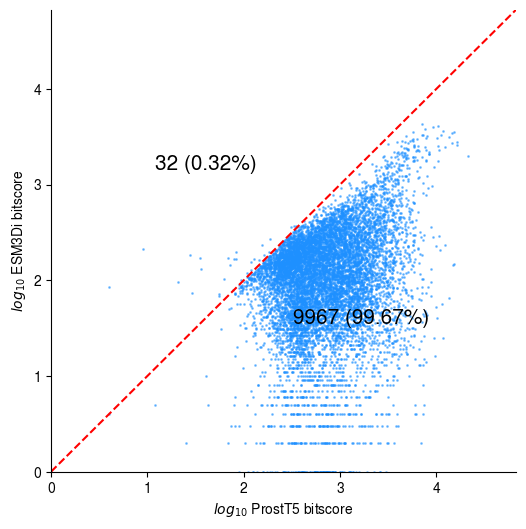

In [ ]:
from pathlib import Path
import os
from matplotlib import pyplot as plt

datapath = Path(os.environ["DATAPATH"])
fig, ax = plt.subplots(figsize=(6, 6))
plt.rcParams['font.family'] = 'Nimbus sans'

x, y = [], []
with open(datapath / "metavr/metavr_bitscores.tsv") as f:
	for line in f:
		identifier, prostt5_score, esm3di_score = line.strip().split()
		x.append(int(prostt5_score))
		y.append(int(esm3di_score))

print(f"Number of points: {len(x)}")



# take log
from math import log10
x = [0 if score <= 0 else log10(score) for score in x]
y = [0 if score <= 0 else log10(score) for score in y]

# get info where x < y / x > y
xsmall = sum(1 for a, b in zip(x, y) if a < b)
xlarge = sum(1 for a, b in zip(x, y) if a > b)

# equalize xlim and ylim
lim = max(max(x), max(y)) + 0.5
plt.xlim(0, lim)
plt.ylim(0, lim)

# scatter plot
plt.scatter(x, y, alpha=0.5, s=1, color='dodgerblue')
plt.plot([0, lim], [0, lim], 'r--')

# print info about how many points are above/below the diagonal
txt_above = f"{xsmall} ({xsmall / len(x) * 100:.2f}%)"
txt_below = f"{xlarge} ({xlarge / len(x) * 100:.2f}%)"

# centers of the two triangles in axes coordinates: (1/3,2/3) and (2/3,1/3)
ax.text(1/3, 2/3, txt_above, transform=ax.transAxes,
	ha="center", va="center", fontsize=15)
ax.text(2/3, 1/3, txt_below, transform=ax.transAxes,
	ha="center", va="center", fontsize=15)

# set labels and title
plt.xlabel('$log_{10}$ ProstT5 bitscore')
plt.ylabel('$log_{10}$ ESM3Di bitscore')

# remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

---

## Identity calculation

### Generate 3Di FASTA files for each representation

In [ ]:
%%bash
# AF3
foldseek base:lndb "$DATAPATH/foldseek/metavr_af3_h" "$DATAPATH/foldseek/metavr_af3_ss_h"
foldseek base:convert2fasta "$DATAPATH/foldseek/metavr_af3_ss" "$DATAPATH/metavr/metavr_af3_3di.fa"

# ProstT5
foldseek base:lndb "$DATAPATH/foldseek/metavr_prostt5_h" "$DATAPATH/foldseek/metavr_prostt5_ss_h"
foldseek base:convert2fasta "$DATAPATH/foldseek/metavr_prostt5_ss" "$DATAPATH/metavr/metavr_prostt5_3di.fa"

# ESM3Di
foldseek base:lndb "$DATAPATH/foldseek/metavr_esm3di_h" "$DATAPATH/foldseek/metavr_esm3di_ss_h"
foldseek base:convert2fasta "$DATAPATH/foldseek/metavr_esm3di_ss" "$DATAPATH/metavr/metavr_esm3di_3di.fa"

/mnt/data1/metavir_structs/foldseek/metavr_af3_ss_h exists and will be overwritten
lndb /mnt/data1/metavir_structs/foldseek/metavr_af3_h /mnt/data1/metavir_structs/foldseek/metavr_af3_ss_h 

MMseqs Version:	10.941cd33
Verbosity	3

Time for processing: 0h 0m 0s 0ms
/mnt/data1/metavir_structs/metavr/metavr_af3_3di.fa exists and will be overwritten
convert2fasta /mnt/data1/metavir_structs/foldseek/metavr_af3_ss /mnt/data1/metavir_structs/metavr/metavr_af3_3di.fa 

MMseqs Version:	10.941cd33
Use header DB	false
Verbosity    	3

Start writing file to /mnt/data1/metavir_structs/metavr/metavr_af3_3di.fa
Time for processing: 0h 0m 0s 9ms
/mnt/data1/metavir_structs/foldseek/metavr_prostt5_ss_h exists and will be overwritten
lndb /mnt/data1/metavir_structs/foldseek/metavr_prostt5_h /mnt/data1/metavir_structs/foldseek/metavr_prostt5_ss_h 

MMseqs Version:	10.941cd33
Verbosity	3

Time for processing: 0h 0m 0s 0ms
/mnt/data1/metavir_structs/metavr/metavr_prostt5_3di.fa exists and will be overwritte

### Generate combined TSV file

In [ ]:
%%bash
# Generate a TSV file with the following columns:
# [MetaVR ID], [AF3 3Di], [ProstT5 3Di], [ESM3Di 3Di]
paste \
	<(awk '{printf "%s\t", $0; getline; print}' "$DATAPATH/metavr/metavr_af3_3di.fa") \
	<(awk '{printf "%s\t", $0; getline; print}' "$DATAPATH/metavr/metavr_prostt5_3di.fa" | sort | cut -f2) \
	<(awk '{printf "%s\t", $0; getline; print}' "$DATAPATH/metavr/metavr_esm3di_3di.fa" | sort | cut -f2) \
	> "$DATAPATH/metavr/metavr_3di_comp.tsv"

# Ensure everything has equal length
awk 'length($2) != length($3) || length($2) != length($4) {print "Sanity check: ERROR"} END{print "Sanity check: OK"}' \
	"$DATAPATH/metavr/metavr_3di_comp.tsv"

Sanity check: OK


### Calculate 3Di identity

In [ ]:
from pathlib import Path
import os

datapath = Path(os.environ["DATAPATH"])
outfile = open(datapath / "metavr/metavr_3di_identity.tsv", 'w')
with open(datapath / "metavr/metavr_3di_comp.tsv") as f:
	for line in f:
		metaVR_id, af3_3di, prostt5_3di, esm3di_3di = line.strip().split('\t')
		metaVR_id = metaVR_id[1:]  # remove '>' from FASTA header

		prostt5_identity = sum(a == b for a, b in zip(af3_3di, prostt5_3di)) / len(af3_3di) * 100
		esm3di_identity = sum(a == b for a, b in zip(af3_3di, esm3di_3di)) / len(af3_3di) * 100

		print(f'{metaVR_id}\t{prostt5_identity:.4f}\t{esm3di_identity:.4f}', file=outfile)
		x.append(prostt5_identity)
		y.append(esm3di_identity)

### Plot identity comparison as a density plot

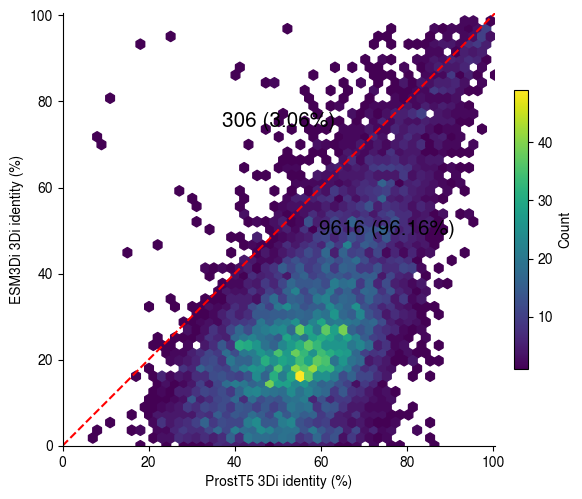

In [ ]:
from pathlib import Path
import os
from matplotlib import pyplot as plt

datapath = Path(os.environ["DATAPATH"])
fig, ax = plt.subplots(figsize=(6, 6))
plt.rcParams['font.family'] = 'Nimbus sans'

x, y = [], []
with open(datapath / "metavr/metavr_3di_identity.tsv") as f:
    for line in f:
        _, prostt5_identity, esm3di_identity = line.strip().split('\t')
        x.append(float(prostt5_identity))
        y.append(float(esm3di_identity))

# get info where x < y / x > y
xsmall = sum(1 for a, b in zip(x, y) if a < b)
xlarge = sum(1 for a, b in zip(x, y) if a > b)

# equalize xlim and ylim
lim = max(max(x), max(y)) + 0.5
plt.xlim(0, lim)
plt.ylim(0, lim)

# density plot with viridis colormap
ax.set_aspect("equal", adjustable="box")   
hb = ax.hexbin(
    x, y,
    gridsize=50,
    extent=(0, lim, 0, lim),
    cmap="viridis",
    mincnt=1,
    #linewidths=0.0,
 )
hb.set_alpha(1)

# add colormap legend indicating the count of points in each hexbin
# make it much smaller
plt.colorbar(hb, ax=ax, label='Count', fraction=0.03, pad=0.04)

plt.plot([0, lim], [0, lim], 'r--')

# print info about how many points are above/below the diagonal
txt_above = f"{xsmall} ({xsmall / len(x) * 100:.2f}%)"
txt_below = f"{xlarge} ({xlarge / len(x) * 100:.2f}%)"

# centers of the two triangles in axes coordinates: (1/3,2/3) and (2/3,1/3)
ax.text(1/2, 3/4, txt_above, transform=ax.transAxes,
	ha="center", va="center", fontsize=15)
ax.text(3/4, 1/2, txt_below, transform=ax.transAxes,
	ha="center", va="center", fontsize=15)

# set labels and title
plt.xlabel('ProstT5 3Di identity (%)')
plt.ylabel('ESM3Di 3Di identity (%)')

# remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()